In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [4]:
# =====================================================================
# Cell 1 (v3) — Data with vocab reduced to top-30K BPE tokens
# =====================================================================
# Loads WT-103, tokenizes with GPT-2 BPE (batched), then maps tokens to
# a reduced vocab of size V'=30000.
#
# Pipeline:
#   1. Tokenize entire train+val with GPT-2 BPE (V=50257) — batched
#   2. Compute frequency on train, take top-(V_NEW-1) most frequent
#   3. Build mapping: original_id -> new_id ∈ [0, V_NEW); OOV -> UNK_ID
#   4. Save remapped train/val token streams
#   5. Save mapping tables (Cell 2 will reuse GPT-2 wte via new_to_old)
#
# Reduces logits from (B, S, 50257) to (B, S, 30000) — ~40% smaller.
# OOV ratio at 30K cutoff is ~0.5% on WT-103.
# =====================================================================
import os
import time
import numpy as np
from transformers import GPT2TokenizerFast
from datasets import load_dataset

os.environ["TOKENIZERS_PARALLELISM"] = "true"

# ---------- config ----------
CACHE_DIR = "/kaggle/working/hdlm_tier1/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

V_NEW  = 30000              # reduced vocab size (last id reserved for <unk>)
UNK_ID = V_NEW - 1
TOK_BATCH = 1000            # lines per tokenizer call

TRAIN_RAW  = f"{CACHE_DIR}/wt103_train_tokens_full50k.npy"
VAL_RAW    = f"{CACHE_DIR}/wt103_val_tokens_full50k.npy"
TRAIN_NEW  = f"{CACHE_DIR}/wt103_train_v30k.npy"
VAL_NEW    = f"{CACHE_DIR}/wt103_val_v30k.npy"
NEW_TO_OLD = f"{CACHE_DIR}/new_to_old_v30k.npy"   # (V_NEW,)  -> orig GPT-2 id
OLD_TO_NEW = f"{CACHE_DIR}/old_to_new_v30k.npy"   # (50257,)  -> new id (or UNK)
FREQ_NEW   = f"{CACHE_DIR}/train_freq_v30k.npy"

tok   = GPT2TokenizerFast.from_pretrained("gpt2")
V_OLD = tok.vocab_size  # 50257
print(f"original vocab : {V_OLD}")
print(f"reduced vocab  : {V_NEW}  (last id = {UNK_ID} as <unk>)")

# ---------------------------------------------------------------------
# Step 1: tokenize WT-103 with GPT-2 BPE (cache raw 50K-vocab streams)
# ---------------------------------------------------------------------
def tokenize_batched(texts, batch_size=TOK_BATCH, label=""):
    """Batched GPT-2 tokenization — much faster than per-line encode()."""
    # Drop empty / whitespace-only lines once
    texts = [t for t in texts if t and t.strip()]
    n = len(texts)
    print(f"  [{label}] {n:,} non-empty lines")

    chunks = []
    t0 = time.time()
    for i in range(0, n, batch_size):
        batch = texts[i:i + batch_size]
        # tokenizer(batch) returns dict with 'input_ids' as list[list[int]]
        enc = tok(batch, add_special_tokens=False)["input_ids"]
        for ids in enc:
            if ids:
                chunks.append(np.asarray(ids, dtype=np.int32))
        # progress every ~50 batches
        if ((i // batch_size) % 50 == 0) and i > 0:
            done = i + len(batch)
            rate = done / (time.time() - t0)
            eta  = (n - done) / max(rate, 1e-6)
            print(f"  [{label}] {done:,}/{n:,} lines  "
                  f"({rate:,.0f} lines/s, ETA {eta:.0f}s)")
    out = np.concatenate(chunks)
    print(f"  [{label}] done: {len(out):,} tokens in {time.time()-t0:.1f}s")
    return out

if not (os.path.exists(TRAIN_RAW) and os.path.exists(VAL_RAW)):
    print("loading WikiText-103 raw...")
    ds = load_dataset("wikitext", "wikitext-103-raw-v1")

    print("tokenizing train...")
    train_raw = tokenize_batched(ds["train"]["text"], label="train")
    np.save(TRAIN_RAW, train_raw)

    print("tokenizing val...")
    val_raw = tokenize_batched(ds["validation"]["text"], label="val")
    np.save(VAL_RAW, val_raw)
else:
    train_raw = np.load(TRAIN_RAW)
    val_raw   = np.load(VAL_RAW)
    print(f"loaded raw: train={len(train_raw):,}, val={len(val_raw):,}")

# ---------------------------------------------------------------------
# Step 2+3: build top-(V_NEW-1) vocab mapping
# ---------------------------------------------------------------------
if not (os.path.exists(NEW_TO_OLD) and os.path.exists(OLD_TO_NEW)):
    print("\ncomputing token frequencies on train (orig 50K vocab)...")
    freq_old = np.bincount(train_raw, minlength=V_OLD).astype(np.int64)
    print(f"  active tokens (freq>0): {(freq_old>0).sum():,} / {V_OLD:,}")
    print(f"  total tokens         : {freq_old.sum():,}")

    # Top (V_NEW-1) most frequent — last new id reserved for UNK
    top_orig_ids = np.argsort(-freq_old)[:V_NEW - 1].astype(np.int32)

    # new_to_old: new_id 0..V_NEW-2 -> top_orig_ids; UNK row is placeholder
    new_to_old = np.zeros(V_NEW, dtype=np.int32)
    new_to_old[:V_NEW - 1] = top_orig_ids
    new_to_old[UNK_ID] = 0   # Cell 2 will fill UNK row with mean of dropped wte

    # old_to_new: default UNK, then overwrite kept ids with their new index
    old_to_new = np.full(V_OLD, UNK_ID, dtype=np.int32)
    old_to_new[top_orig_ids] = np.arange(V_NEW - 1, dtype=np.int32)

    # Coverage stats
    kept_freq = freq_old[top_orig_ids].sum()
    coverage  = kept_freq / freq_old.sum() * 100
    oov_ratio = 100 - coverage
    print(f"  top-{V_NEW-1} coverage   : {coverage:.3f}%  (OOV: {oov_ratio:.3f}%)")

    np.save(NEW_TO_OLD, new_to_old)
    np.save(OLD_TO_NEW, old_to_new)
    print("  saved mapping tables")
else:
    new_to_old = np.load(NEW_TO_OLD)
    old_to_new = np.load(OLD_TO_NEW)
    print("loaded existing mappings")

# ---------------------------------------------------------------------
# Step 4: remap train/val to new vocab
# ---------------------------------------------------------------------
if not (os.path.exists(TRAIN_NEW) and os.path.exists(VAL_NEW)):
    print("\nremapping train/val to V=30K...")
    t0 = time.time()
    train_new = old_to_new[train_raw]
    val_new   = old_to_new[val_raw]
    np.save(TRAIN_NEW, train_new)
    np.save(VAL_NEW,   val_new)

    unk_pct_tr = (train_new == UNK_ID).mean() * 100
    unk_pct_va = (val_new   == UNK_ID).mean() * 100
    print(f"  done in {time.time()-t0:.1f}s")
    print(f"  train UNK ratio: {unk_pct_tr:.3f}%")
    print(f"  val   UNK ratio: {unk_pct_va:.3f}%")
else:
    train_new = np.load(TRAIN_NEW)
    val_new   = np.load(VAL_NEW)
    print(f"loaded remapped: train={len(train_new):,}, val={len(val_new):,}")

# ---------------------------------------------------------------------
# Step 5: train freq in NEW vocab (Cell 2 uses this for clusters)
# ---------------------------------------------------------------------
if not os.path.exists(FREQ_NEW):
    print("\ncomputing train frequencies in V=30K...")
    freq_new = np.bincount(train_new, minlength=V_NEW).astype(np.int64)
    np.save(FREQ_NEW, freq_new)
    print(f"  most frequent new id : {freq_new.argmax()} (count {freq_new.max():,})")
    print(f"  zero-freq new ids    : {(freq_new==0).sum():,}")
else:
    freq_new = np.load(FREQ_NEW)
    print(f"loaded freq_new: shape={freq_new.shape}")

# ---------------------------------------------------------------------
print(f"\n{'='*60}")
print(f"V=30K data ready:")
print(f"  train          : {len(train_new):,} tokens")
print(f"  val            : {len(val_new):,} tokens")
print(f"  UNK id         : {UNK_ID}")
print(f"  new_to_old     : {new_to_old.shape}")
print(f"  old_to_new     : {old_to_new.shape}")
print(f"{'='*60}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

original vocab : 50257
reduced vocab  : 30000  (last id = 29999 as <unk>)
loaded raw: train=117,920,140, val=247,289
loaded existing mappings
loaded remapped: train=117,920,140, val=247,289
loaded freq_new: shape=(30000,)

V=30K data ready:
  train          : 117,920,140 tokens
  val            : 247,289 tokens
  UNK id         : 29999
  new_to_old     : (30000,)
  old_to_new     : (50257,)


In [5]:
# =====================================================================
# Cell 2 — Embeddings (V=30K) + Semantic Clusters
# =====================================================================
# Builds the artifacts Cell 3 (HDLM training) needs:
#
#   1. wte_30k   : (V_NEW, D) GPT-2 token embeddings sliced to V=30K.
#                  UNK row = mean of dropped (OOV) embeddings.
#   2. clusters  : (V_NEW,) cluster id ∈ [0, K) for each new token id.
#                  K-means on L2-normalized embeddings, freq-weighted.
#   3. cluster_centroids : (K, D) — used as cluster-level "embeddings"
#                          for the middle hierarchy in HDLM.
#
# Notes:
#   - We L2-normalize embeddings before K-means (cosine-like clustering)
#     because GPT-2 wte magnitudes don't carry semantic meaning.
#   - Freq-weighting: high-freq tokens get more "votes" by being
#     replicated in the K-means input. Caps prevent the top tokens
#     from dominating.
#   - UNK is assigned to its own singleton cluster (last cluster id).
# =====================================================================
import os, time
import numpy as np
import torch
from transformers import GPT2LMHeadModel
from sklearn.cluster import MiniBatchKMeans

CACHE_DIR = "/kaggle/working/hdlm_tier1/cache"

# ---- inputs from Cell 1 ----
NEW_TO_OLD = f"{CACHE_DIR}/new_to_old_v30k.npy"
OLD_TO_NEW = f"{CACHE_DIR}/old_to_new_v30k.npy"
FREQ_NEW   = f"{CACHE_DIR}/train_freq_v30k.npy"

# ---- outputs ----
WTE_30K     = f"{CACHE_DIR}/wte_v30k.npy"          # (V_NEW, D) float32
CLUSTERS    = f"{CACHE_DIR}/clusters_v30k.npy"     # (V_NEW,)   int32
CENTROIDS   = f"{CACHE_DIR}/cluster_centroids.npy" # (K, D)     float32

# ---- config ----
V_NEW   = 30000
UNK_ID  = V_NEW - 1
K       = 1000           # number of semantic clusters (excluding UNK singleton)
FREQ_CAP = 5000          # cap each token's freq-weight in K-means input
KMEANS_BATCH = 4096
KMEANS_ITERS = 100
SEED = 42

# ---------------------------------------------------------------------
# 1. Slice GPT-2 wte to V=30K
# ---------------------------------------------------------------------
new_to_old = np.load(NEW_TO_OLD)   # (V_NEW,)
old_to_new = np.load(OLD_TO_NEW)   # (V_OLD,)
freq_new   = np.load(FREQ_NEW)     # (V_NEW,)
V_OLD = old_to_new.shape[0]

if not os.path.exists(WTE_30K):
    print("loading GPT-2 to extract wte...")
    t0 = time.time()
    gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
    wte_full = gpt2.transformer.wte.weight.detach().cpu().numpy().astype(np.float32)
    del gpt2
    D = wte_full.shape[1]
    print(f"  full wte: {wte_full.shape} (loaded in {time.time()-t0:.1f}s)")

    # Slice: kept rows from new_to_old[:V_NEW-1]
    kept_old_ids = new_to_old[:V_NEW - 1]
    wte_30k = np.zeros((V_NEW, D), dtype=np.float32)
    wte_30k[:V_NEW - 1] = wte_full[kept_old_ids]

    # UNK row = mean of dropped embeddings
    kept_mask = np.zeros(V_OLD, dtype=bool)
    kept_mask[kept_old_ids] = True
    dropped_ids = np.where(~kept_mask)[0]
    print(f"  kept   : {kept_mask.sum():,} / {V_OLD:,}")
    print(f"  dropped: {len(dropped_ids):,}")
    wte_30k[UNK_ID] = wte_full[dropped_ids].mean(axis=0)

    np.save(WTE_30K, wte_30k)
    print(f"  saved {WTE_30K}  shape={wte_30k.shape}")
    del wte_full
else:
    wte_30k = np.load(WTE_30K)
    print(f"loaded wte_30k: {wte_30k.shape}")

D = wte_30k.shape[1]

# ---------------------------------------------------------------------
# 2. Semantic clustering (K-means on L2-normalized, freq-weighted wte)
# ---------------------------------------------------------------------
if not (os.path.exists(CLUSTERS) and os.path.exists(CENTROIDS)):
    print(f"\nclustering {V_NEW-1} non-UNK tokens into K={K} clusters...")
    # Exclude UNK from clustering — it gets its own singleton at the end
    X = wte_30k[:V_NEW - 1].copy()                   # (V_NEW-1, D)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-8)
    Xn = X / norms                                   # L2-normalized

    # Freq weighting: replicate rows by min(freq, FREQ_CAP)
    w = np.minimum(freq_new[:V_NEW - 1], FREQ_CAP).astype(np.int64)
    # Ensure every token shows up at least once
    w = np.maximum(w, 1)
    print(f"  weighted sample size: {w.sum():,} (cap per token: {FREQ_CAP})")

    # Build replicated input — but this can be huge. Use sample_weight instead
    # if sklearn version supports it; MiniBatchKMeans does support it.
    print(f"  running MiniBatchKMeans (K={K}, batch={KMEANS_BATCH}, "
          f"iters={KMEANS_ITERS})...")
    t0 = time.time()
    km = MiniBatchKMeans(
        n_clusters=K,
        batch_size=KMEANS_BATCH,
        max_iter=KMEANS_ITERS,
        n_init=3,
        random_state=SEED,
        verbose=0,
    )
    km.fit(Xn, sample_weight=w)
    print(f"  done in {time.time()-t0:.1f}s  (inertia={km.inertia_:.2f})")

    labels_no_unk = km.labels_.astype(np.int32)      # (V_NEW-1,)
    centroids     = km.cluster_centers_.astype(np.float32)  # (K, D)

    # Build full clusters array: UNK gets its own cluster id = K
    clusters = np.empty(V_NEW, dtype=np.int32)
    clusters[:V_NEW - 1] = labels_no_unk
    clusters[UNK_ID] = K  # singleton cluster for UNK
    K_TOTAL = K + 1

    # Sanity: cluster size distribution
    sizes = np.bincount(clusters, minlength=K_TOTAL)
    print(f"  cluster sizes (token count):")
    print(f"    min = {sizes[:K].min():,}")
    print(f"    max = {sizes[:K].max():,}")
    print(f"    mean= {sizes[:K].mean():.1f}")
    print(f"    median= {int(np.median(sizes[:K]))}")
    print(f"    UNK singleton: {sizes[K]} token (should be 1)")

    # Append UNK centroid (= UNK embedding, normalized) to centroids for parity
    unk_emb = wte_30k[UNK_ID]
    unk_emb = unk_emb / max(np.linalg.norm(unk_emb), 1e-8)
    centroids_full = np.concatenate([centroids, unk_emb[None, :]], axis=0)

    np.save(CLUSTERS, clusters)
    np.save(CENTROIDS, centroids_full)
    print(f"  saved clusters: {clusters.shape}, centroids: {centroids_full.shape}")
else:
    clusters = np.load(CLUSTERS)
    centroids_full = np.load(CENTROIDS)
    K_TOTAL = centroids_full.shape[0]
    print(f"loaded clusters: {clusters.shape}, centroids: {centroids_full.shape}")

# ---------------------------------------------------------------------
# 3. Quick qualitative check — show a few clusters with example tokens
# ---------------------------------------------------------------------
print("\nsample clusters (top-5 most frequent token per cluster):")
from transformers import GPT2TokenizerFast
tok = GPT2TokenizerFast.from_pretrained("gpt2")

# Look at a few random clusters
rng = np.random.default_rng(SEED)
sample_clusters = rng.choice(K_TOTAL - 1, size=5, replace=False)

for c in sample_clusters:
    members = np.where(clusters == c)[0]                # new ids in cluster c
    if len(members) == 0:
        continue
    # Sort by freq desc, take top-5
    member_freq = freq_new[members]
    top = members[np.argsort(-member_freq)[:5]]
    old_ids = new_to_old[top]
    words = [repr(tok.decode([int(oid)])) for oid in old_ids]
    print(f"  cluster {c:4d} ({len(members):4d} tokens): {', '.join(words)}")

print(f"\n{'='*60}")
print(f"Cell 2 done:")
print(f"  wte_30k        : {wte_30k.shape}    ({wte_30k.dtype})")
print(f"  clusters       : {clusters.shape}    K_total={K_TOTAL}")
print(f"  centroids      : {centroids_full.shape}")
print(f"{'='*60}")

loaded wte_30k: (30000, 768)
loaded clusters: (30000,), centroids: (1001, 768)

sample clusters (top-5 most frequent token per cluster):
  cluster  771 (  29 tokens): ' is', ' has', ' does', ' takes', ' makes'
  cluster  438 (   2 tokens): ' perception', ' perceptions'
  cluster  653 (   1 tokens): 'ache'
  cluster   88 (   6 tokens): ' security', ' protection', ' safety', ' maintenance', ' Security'
  cluster  433 (   2 tokens): ' insect', ' Insect'

Cell 2 done:
  wte_30k        : (30000, 768)    (float32)
  clusters       : (30000,)    K_total=1001
  centroids      : (1001, 768)


In [6]:
# =====================================================================
# Cell 2.5 — Three K=64 cluster assignments for ablation
# =====================================================================
# Builds three cluster_map files for the random vs semantic ablation:
#
#   1. clusters_semantic_k64.npy
#      MiniBatchKMeans on L2-normalized GPT-2 wte (freq-weighted).
#      Replaces the K=1000 semantic clusters with K=64.
#
#   2. clusters_rand_matched_k64.npy
#      Same cluster size distribution as semantic, but token-to-cluster
#      assignments are randomly shuffled. Controls for size effects.
#
#   3. clusters_rand_uniform_k64.npy
#      Each token assigned to a uniformly-random cluster in [0, K).
#      Serves as the "no structure at all" baseline.
#
# Why three? — separates two confounds:
#   semantic vs rand_matched : tests semantic CONTENT effect
#   rand_matched vs rand_uniform : tests cluster SIZE distribution effect
#
# UNK token gets its own singleton cluster (id = K) in all three.
# =====================================================================
import os, time
import numpy as np
from sklearn.cluster import MiniBatchKMeans

CACHE_DIR = "/kaggle/working/hdlm_tier1/cache"

# inputs (from Cell 1 v3 + Cell 2)
WTE_30K   = f"{CACHE_DIR}/wte_v30k.npy"
FREQ_NEW  = f"{CACHE_DIR}/train_freq_v30k.npy"
NEW_TO_OLD = f"{CACHE_DIR}/new_to_old_v30k.npy"

# outputs
SEM_K64    = f"{CACHE_DIR}/clusters_semantic_k64.npy"
RMATCH_K64 = f"{CACHE_DIR}/clusters_rand_matched_k64.npy"
RUNIF_K64  = f"{CACHE_DIR}/clusters_rand_uniform_k64.npy"

V_NEW   = 30000
UNK_ID  = V_NEW - 1
K       = 64
FREQ_CAP = 5000
SEED = 42

# ---------------------------------------------------------------------
# Load inputs
# ---------------------------------------------------------------------
wte_30k  = np.load(WTE_30K)             # (V_NEW, D)
freq_new = np.load(FREQ_NEW)            # (V_NEW,)
print(f"loaded wte_30k {wte_30k.shape}, freq_new {freq_new.shape}")
D = wte_30k.shape[1]

# ---------------------------------------------------------------------
# 1. Semantic clusters (K=64)
# ---------------------------------------------------------------------
if not os.path.exists(SEM_K64):
    print(f"\n[1/3] semantic K-means (K={K}, V={V_NEW-1} non-UNK tokens)...")
    X = wte_30k[:V_NEW - 1].copy()
    norms = np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-8)
    Xn = X / norms

    w = np.minimum(freq_new[:V_NEW - 1], FREQ_CAP).astype(np.int64)
    w = np.maximum(w, 1)

    t0 = time.time()
    km = MiniBatchKMeans(
        n_clusters=K,
        batch_size=4096,
        max_iter=100,
        n_init=3,
        random_state=SEED,
        verbose=0,
    )
    km.fit(Xn, sample_weight=w)
    print(f"  done in {time.time()-t0:.1f}s  (inertia={km.inertia_:.2f})")

    labels = km.labels_.astype(np.int32)
    clusters_sem = np.empty(V_NEW, dtype=np.int32)
    clusters_sem[:V_NEW - 1] = labels
    clusters_sem[UNK_ID]     = K   # UNK singleton

    sizes = np.bincount(clusters_sem, minlength=K + 1)
    print(f"  cluster sizes (excluding UNK):  "
          f"min={sizes[:K].min()}  max={sizes[:K].max()}  "
          f"mean={sizes[:K].mean():.1f}  median={int(np.median(sizes[:K]))}")
    np.save(SEM_K64, clusters_sem)
else:
    clusters_sem = np.load(SEM_K64)
    sizes = np.bincount(clusters_sem, minlength=K + 1)
    print(f"loaded existing semantic clusters: "
          f"min={sizes[:K].min()} max={sizes[:K].max()} mean={sizes[:K].mean():.1f}")

# ---------------------------------------------------------------------
# 2. Random matched-size: shuffle token assignments while keeping
#    cluster sizes identical to semantic
# ---------------------------------------------------------------------
if not os.path.exists(RMATCH_K64):
    print(f"\n[2/3] random matched-size (same sizes as semantic, shuffled assignments)...")
    rng = np.random.default_rng(SEED + 1)
    # Take semantic labels for non-UNK tokens, shuffle them
    sem_labels = clusters_sem[:V_NEW - 1].copy()
    rng.shuffle(sem_labels)            # in-place permutation

    clusters_rm = np.empty(V_NEW, dtype=np.int32)
    clusters_rm[:V_NEW - 1] = sem_labels
    clusters_rm[UNK_ID]     = K        # UNK singleton

    # Sanity: size distribution must match semantic exactly
    sizes_rm  = np.bincount(clusters_rm,  minlength=K + 1)
    sizes_sem = np.bincount(clusters_sem, minlength=K + 1)
    assert np.array_equal(np.sort(sizes_rm[:K]), np.sort(sizes_sem[:K])), \
        "matched-size invariant violated"
    print(f"  size distribution matches semantic: OK")
    print(f"  min={sizes_rm[:K].min()} max={sizes_rm[:K].max()} "
          f"mean={sizes_rm[:K].mean():.1f}")
    np.save(RMATCH_K64, clusters_rm)
else:
    clusters_rm = np.load(RMATCH_K64)
    print("loaded existing random matched-size clusters")

# ---------------------------------------------------------------------
# 3. Random uniform: each token uniformly random cluster in [0, K)
# ---------------------------------------------------------------------
if not os.path.exists(RUNIF_K64):
    print(f"\n[3/3] random uniform (each token i.i.d. ~ Uniform[0, K))...")
    rng = np.random.default_rng(SEED + 2)
    labels = rng.integers(0, K, size=V_NEW - 1, dtype=np.int32)

    clusters_ru = np.empty(V_NEW, dtype=np.int32)
    clusters_ru[:V_NEW - 1] = labels
    clusters_ru[UNK_ID]     = K        # UNK singleton

    sizes_ru = np.bincount(clusters_ru, minlength=K + 1)
    print(f"  size distribution:  "
          f"min={sizes_ru[:K].min()} max={sizes_ru[:K].max()} "
          f"mean={sizes_ru[:K].mean():.1f} std={sizes_ru[:K].std():.1f}")
    np.save(RUNIF_K64, clusters_ru)
else:
    clusters_ru = np.load(RUNIF_K64)
    print("loaded existing random uniform clusters")

# ---------------------------------------------------------------------
# Quick comparative summary
# ---------------------------------------------------------------------
print(f"\n{'='*60}")
print(f"Three K={K} cluster assignments ready:")
print(f"{'='*60}")
print(f"{'method':<22s}  {'min':>5s}  {'max':>5s}  {'mean':>7s}  {'std':>7s}")
for label, c in [("semantic",     clusters_sem),
                 ("rand_matched", clusters_rm),
                 ("rand_uniform", clusters_ru)]:
    sz = np.bincount(c, minlength=K + 1)[:K]
    print(f"{label:<22s}  {sz.min():>5d}  {sz.max():>5d}  "
          f"{sz.mean():>7.1f}  {sz.std():>7.1f}")
print(f"\nUNK ({UNK_ID}) is in singleton cluster {K} for all three.")

# ---------------------------------------------------------------------
# Sanity: peek at a few semantic clusters
# ---------------------------------------------------------------------
print(f"\nSample semantic clusters (top-5 most frequent token):")
from transformers import GPT2TokenizerFast
tok = GPT2TokenizerFast.from_pretrained("gpt2")
new_to_old = np.load(NEW_TO_OLD)
rng = np.random.default_rng(SEED)
sample = rng.choice(K, size=4, replace=False)
for c in sample:
    members = np.where(clusters_sem[:V_NEW - 1] == c)[0]
    if len(members) == 0:
        continue
    top = members[np.argsort(-freq_new[members])[:5]]
    words = [repr(tok.decode([int(new_to_old[i])])) for i in top]
    print(f"  cluster {c:2d} ({len(members):4d} tokens): {', '.join(words)}")

print(f"\nReady for Cell 3 (model + benchmark).")

loaded wte_30k (30000, 768), freq_new (30000,)
loaded existing semantic clusters: min=2 max=2433 mean=468.7
loaded existing random matched-size clusters
loaded existing random uniform clusters

Three K=64 cluster assignments ready:
method                    min    max     mean      std
semantic                    2   2433    468.7    546.8
rand_matched                2   2433    468.7    546.8
rand_uniform              424    516    468.7     22.2

UNK (29999) is in singleton cluster 64 for all three.

Sample semantic clusters (top-5 most frequent token):
  cluster 28 ( 568 tokens): ' critics', 'ians', ' students', ' fans', ' soldiers'
  cluster  5 ( 253 tokens): ' game', ' games', ' Game', ' Final', ' Fox'
  cluster 41 (  36 tokens): ' team', ' group', ' members', ' company', ' member'
  cluster 47 ( 522 tokens): 'ian', 'ic', 'ist', 'ated', 'ism'

Ready for Cell 3 (model + benchmark).


In [9]:
# =====================================================================
# Cell 3 v3 — Minimal Hierarchical Masked LM (Karpathy-style)
# =====================================================================
# Drops HDLM's exact 3-state diffusion in favor of a clean BERT-style
# masked LM with TWO prediction heads:
#   - cluster head (H -> K+1)
#   - word head    (H -> V) [tied to input embedding]
#
# At each masked position:
#   loss = CE(cluster_logits, true_cluster)
#        + CE(word_logits,    true_word)
#
# This is sufficient for the critique we're testing:
#   "does semantic clustering help vs random?"
#
# What we GIVE UP vs full HDLM:
#   - exact 3-state diffusion (word/cluster/mask)
#   - alpha/beta time schedule
#   - HDLM-specific ELBO weighting
# What we KEEP (the only thing that matters):
#   - same model architecture across conditions
#   - same data, same compute
#   - cluster_map is the only thing that varies
#     -> any perplexity difference attributable to the cluster mapping
#
# Memory: full V=30K softmax with cross_entropy is OK. PyTorch fuses it.
#         (BS=16, S=256, V=30000) fp16 logits = 245MB. T4 has 15GB.
#
# Architecture:
#   - 6 layers, 384 hidden, 6 heads, max_len=256
#   - bidirectional (no causal mask)
#   - tied input/output word embeddings
#
# This cell:
#   1. Defines the model + loss (50 lines, no clever tricks)
#   2. Builds model and runs sanity benchmark
#   3. Reports timing for the 9-run sweep
# =====================================================================
import os, time, gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

CACHE_DIR = "/kaggle/working/hdlm_tier1/cache"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# ---- config ----
V          = 30000
K_PLUS_UNK = 65         # 64 clusters + 1 UNK singleton
H          = 384
L          = 6
NHEAD      = 6
MAX_LEN    = 256
MASK_RATIO = 0.15

# ---------------------------------------------------------------------
# Model — single embedding for words; cluster info comes ONLY from labels
# ---------------------------------------------------------------------
# Note: we don't embed cluster IDs. Clusters are only a TARGET (output)
# for the cluster head. The model's input is just word ids (or [MASK]).
# This is a clean ablation: only the cluster_map (which clusters get
# which labels) varies between conditions.
#
# Embedding table: V word ids + 1 MASK id = V + 1
# ---------------------------------------------------------------------
class HierMLM(nn.Module):
    def __init__(self, V, K_total, H, n_layers, n_heads, max_len):
        super().__init__()
        self.V = V
        self.K_total = K_total           # cluster vocab size (incl. UNK singleton)
        self.MASK_ID = V                  # mask token sits at index V

        # +1 for the mask token
        self.embed = nn.Embedding(V + 1, H)
        self.pos   = nn.Embedding(max_len, H)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=H, nhead=n_heads, dim_feedforward=4*H,
            dropout=0.1, batch_first=True, norm_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(H)

        # Output heads
        # word head: tied to input embedding (use first V rows)
        # cluster head: separate small matrix (H -> K_total)
        self.cluster_head = nn.Linear(H, K_total, bias=True)

        nn.init.normal_(self.embed.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pos.weight,   mean=0.0, std=0.02)

    def forward(self, input_ids):
        """
        input_ids: (B, S) long. Either word id in [0, V) or MASK_ID = V.
        Returns:
            h: (B, S, H)
        """
        B, S = input_ids.shape
        x = self.embed(input_ids)
        positions = torch.arange(S, device=input_ids.device).unsqueeze(0)
        x = x + self.pos(positions)
        h = self.encoder(x)
        h = self.norm(h)
        return h

    def word_logits(self, h):
        # tied embedding: words are at indices [0, V) of self.embed
        W = self.embed.weight[:self.V]      # (V, H)
        return h @ W.t()                     # (B, S, V)

    def cluster_logits(self, h):
        return self.cluster_head(h)          # (B, S, K_total)

# ---------------------------------------------------------------------
# Masking
# ---------------------------------------------------------------------
def mask_batch(x, mask_ratio, mask_id):
    """
    BERT-style masking. Returns:
        input_ids: (B, S) — x with mask_ratio fraction replaced by mask_id
        target_mask: (B, S) bool — True at masked positions
    """
    target_mask = torch.rand_like(x, dtype=torch.float) < mask_ratio
    input_ids = torch.where(target_mask, torch.full_like(x, mask_id), x)
    return input_ids, target_mask

# ---------------------------------------------------------------------
# Loss
# ---------------------------------------------------------------------
def hier_mlm_loss(model, x, cluster_map, mask_ratio=MASK_RATIO):
    """
    x: (B, S) clean token ids in [0, V)
    cluster_map: (V,) -> cluster id in [0, K_total)
    Returns:
        loss: scalar
        word_nll: scalar (avg over masked positions)
        cluster_nll: scalar (avg over masked positions)
    """
    input_ids, target_mask = mask_batch(x, mask_ratio, model.MASK_ID)

    h = model(input_ids)                                    # (B, S, H)

    # only compute loss at masked positions to save memory + match BERT
    h_masked = h[target_mask]                               # (M, H)
    x_target = x[target_mask]                               # (M,)
    c_target = cluster_map[x_target]                        # (M,)

    # word head — full V softmax, but only on M masked positions
    # M ~ 0.15 * B * S. For B=16, S=256, M ~ 614. Logits = (M, V) = (614, 30000) = 73MB. OK.
    w_logits = h_masked @ model.embed.weight[:model.V].t()  # (M, V)
    word_nll = F.cross_entropy(w_logits, x_target)

    # cluster head — small
    c_logits = model.cluster_logits(h_masked)               # (M, K_total)
    cluster_nll = F.cross_entropy(c_logits, c_target)

    loss = word_nll + cluster_nll
    return loss, word_nll.detach(), cluster_nll.detach()

# =====================================================================
# Setup
# =====================================================================
print("\nLoading semantic cluster map...")
cm_np = np.load(f"{CACHE_DIR}/clusters_semantic_k64.npy")
K_total = int(cm_np.max()) + 1
print(f"  cluster_map: shape={cm_np.shape}, "
      f"range=[{cm_np.min()}, {cm_np.max()}], K_total={K_total}")

cluster_map = torch.from_numpy(cm_np).long().to(device)

model = HierMLM(V=V, K_total=K_total, H=H,
                n_layers=L, n_heads=NHEAD, max_len=MAX_LEN).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  params: {n_params/1e6:.2f}M")

# =====================================================================
# Sanity benchmark
# =====================================================================
print("\n--- Sanity test: BS=16, S=256 ---")
gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

BS = 16
torch.manual_seed(0)
x = torch.randint(0, V, (BS, MAX_LEN), device=device)

optim = torch.optim.AdamW(model.parameters(), lr=3e-4)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")

# warmup + measure
n_warm, n_iter = 3, 10
times = []
for i in range(n_warm + n_iter):
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    with torch.amp.autocast("cuda", dtype=torch.float16,
                             enabled=device.type == "cuda"):
        loss, w_nll, c_nll = hier_mlm_loss(model, x, cluster_map, MASK_RATIO)
    optim.zero_grad(set_to_none=True)
    if scaler.is_enabled():
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
    else:
        loss.backward()
        optim.step()
    if device.type == "cuda":
        torch.cuda.synchronize()
    if i >= n_warm:
        times.append(time.time() - t0)

avg_ms = 1000 * sum(times) / len(times)
peak_gb = torch.cuda.max_memory_allocated() / 1e9 if device.type == "cuda" else 0

print(f"\n✓ SANITY PASSED")
print(f"  step time : {avg_ms:.1f} ms  (BS={BS}, S={MAX_LEN})")
print(f"  peak mem  : {peak_gb:.2f} GB / 15 GB")
print(f"  loss      : {loss.item():.4f}  (word={w_nll.item():.3f}, cluster={c_nll.item():.3f})")

# Try BS=32
print(f"\n--- Trying BS=32 for comparison ---")
del optim
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

try:
    BS2 = 32
    x2 = torch.randint(0, V, (BS2, MAX_LEN), device=device)
    optim2 = torch.optim.AdamW(model.parameters(), lr=3e-4)
    scaler2 = torch.amp.GradScaler("cuda")
    times2 = []
    for i in range(n_warm + n_iter):
        torch.cuda.synchronize()
        t0 = time.time()
        with torch.amp.autocast("cuda", dtype=torch.float16):
            loss2, _, _ = hier_mlm_loss(model, x2, cluster_map, MASK_RATIO)
        optim2.zero_grad(set_to_none=True)
        scaler2.scale(loss2).backward()
        scaler2.step(optim2)
        scaler2.update()
        torch.cuda.synchronize()
        if i >= n_warm:
            times2.append(time.time() - t0)
    avg2 = 1000 * sum(times2) / len(times2)
    peak2 = torch.cuda.max_memory_allocated() / 1e9
    print(f"  BS=32 step time: {avg2:.1f} ms, peak mem: {peak2:.2f} GB")
except torch.cuda.OutOfMemoryError:
    print(f"  BS=32 OOM — stick with BS=16")
    avg2 = None

# =====================================================================
# Projections
# =====================================================================
print(f"\n=== 9-run sweep projections ===")
for label, ms in [("BS=16", avg_ms)] + ([("BS=32", avg2)] if avg2 else []):
    per_run_min = ms / 1000.0 * 20_000 / 60
    total_h = per_run_min * 9 / 60
    flag = "✓" if total_h <= 10 else ("⚠️ tight" if total_h <= 12 else "❌ too long")
    print(f"  {label}: per-run={per_run_min:.1f}min, 9 runs={total_h:.2f}h  {flag}")

print(f"\nReady for Cell 4 (training sweep) if sanity passed.")

device: cuda

Loading semantic cluster map...
  cluster_map: shape=(30000,), range=[0, 64], K_total=65


/tmp/ipykernel_55/3256914853.py:84: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


  params: 22.29M

--- Sanity test: BS=16, S=256 ---

✓ SANITY PASSED
  step time : 49.8 ms  (BS=16, S=256)
  peak mem  : 1.38 GB / 15 GB
  loss      : 13.0721  (word=9.472, cluster=3.600)

--- Trying BS=32 for comparison ---
  BS=32 step time: 85.5 ms, peak mem: 1.60 GB

=== 9-run sweep projections ===
  BS=16: per-run=16.6min, 9 runs=2.49h  ✓
  BS=32: per-run=28.5min, 9 runs=4.27h  ✓

Ready for Cell 4 (training sweep) if sanity passed.


In [10]:
# =====================================================================
# Cell 4 — Single-run training function
# =====================================================================
# Trains one HierMLM model with a given cluster_map and seed.
# Saves results to JSON for the sweep to aggregate.
#
# Reuses HierMLM, hier_mlm_loss from Cell 3 v3 (already in scope).
# =====================================================================
import os, json, time, math
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

CACHE_DIR  = "/kaggle/working/hdlm_tier1/cache"
RESULT_DIR = "/kaggle/working/hdlm_tier1/results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ---- training config ----
TOTAL_STEPS    = 20_000
BATCH_SIZE     = 32
SEQ_LEN        = MAX_LEN              # from Cell 3 = 256
LR             = 3e-4
WARMUP_STEPS   = 500
WEIGHT_DECAY   = 0.01
GRAD_CLIP      = 1.0
LOG_INTERVAL   = 500
EVAL_INTERVAL  = 2_000
EVAL_BATCHES   = 50
NUM_WORKERS    = 2

# ---------------------------------------------------------------------
# Dataset — chunks of contiguous tokens
# ---------------------------------------------------------------------
class ChunkedTokens(Dataset):
    """Splits a 1D token stream into non-overlapping chunks of seq_len."""
    def __init__(self, token_path, seq_len):
        self.tokens = np.load(token_path, mmap_mode="r")
        self.seq_len = seq_len
        self.n_chunks = len(self.tokens) // seq_len

    def __len__(self):
        return self.n_chunks

    def __getitem__(self, idx):
        start = idx * self.seq_len
        chunk = self.tokens[start : start + self.seq_len]
        return torch.from_numpy(chunk.astype(np.int64))

# ---------------------------------------------------------------------
# LR schedule: linear warmup + cosine decay
# ---------------------------------------------------------------------
def lr_lambda(step, warmup, total):
    if step < warmup:
        return step / max(1, warmup)
    progress = (step - warmup) / max(1, total - warmup)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

# ---------------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, val_loader, cluster_map, n_batches):
    model.eval()
    word_nll_sum, cluster_nll_sum, n = 0.0, 0.0, 0
    for i, batch in enumerate(val_loader):
        if i >= n_batches:
            break
        x = batch.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", dtype=torch.float16):
            _, w_nll, c_nll = hier_mlm_loss(model, x, cluster_map, MASK_RATIO)
        word_nll_sum    += w_nll.item()
        cluster_nll_sum += c_nll.item()
        n += 1
    model.train()
    return word_nll_sum / max(n, 1), cluster_nll_sum / max(n, 1)

# ---------------------------------------------------------------------
# Single training run
# ---------------------------------------------------------------------
def train_one_run(method, seed, cluster_map_path, total_steps=TOTAL_STEPS,
                  batch_size=BATCH_SIZE, log_interval=LOG_INTERVAL,
                  eval_interval=EVAL_INTERVAL, save=True):
    """
    Train one model.
    Args:
      method: 'semantic' / 'rand_matched' / 'rand_uniform'
      seed: integer
      cluster_map_path: .npy file with cluster assignments
    Returns:
      result dict
    """
    run_id = f"{method}_seed{seed}"
    out_path = f"{RESULT_DIR}/{run_id}.json"

    if save and os.path.exists(out_path):
        with open(out_path) as f:
            result = json.load(f)
        if result.get("complete"):
            print(f"[skip] {run_id} already complete (val_word_nll={result['final_val_word_nll']:.4f})")
            return result

    print(f"\n{'='*60}")
    print(f"RUN: {run_id}")
    print(f"  cluster_map: {cluster_map_path}")
    print(f"  steps={total_steps}, bs={batch_size}, lr={LR}")
    print(f"{'='*60}")

    # seed everything
    torch.manual_seed(seed)
    np.random.seed(seed)

    # load cluster_map
    cm_np = np.load(cluster_map_path)
    K_total_local = int(cm_np.max()) + 1
    cluster_map_local = torch.from_numpy(cm_np).long().to(device)

    # data
    train_ds = ChunkedTokens(f"{CACHE_DIR}/wt103_train_v30k.npy", SEQ_LEN)
    val_ds   = ChunkedTokens(f"{CACHE_DIR}/wt103_val_v30k.npy",   SEQ_LEN)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    print(f"  train chunks: {len(train_ds):,} | val chunks: {len(val_ds):,}")

    # fresh model
    model = HierMLM(V=V, K_total=K_total_local, H=H,
                    n_layers=L, n_heads=NHEAD, max_len=MAX_LEN).to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optim, lr_lambda=lambda s: lr_lambda(s, WARMUP_STEPS, total_steps))
    scaler = torch.amp.GradScaler("cuda")

    # train
    model.train()
    step = 0
    t_start = time.time()
    train_iter = iter(train_loader)
    log = {"step": [], "train_word_nll": [], "train_cluster_nll": [],
           "val_step": [], "val_word_nll": [], "val_cluster_nll": []}

    while step < total_steps:
        try:
            batch = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            batch = next(train_iter)

        x = batch.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", dtype=torch.float16):
            loss, w_nll, c_nll = hier_mlm_loss(model, x, cluster_map_local, MASK_RATIO)

        optim.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optim)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optim)
        scaler.update()
        scheduler.step()
        step += 1

        if step % log_interval == 0 or step == 1:
            elapsed = time.time() - t_start
            steps_per_s = step / elapsed
            eta_s = (total_steps - step) / steps_per_s
            current_lr = optim.param_groups[0]["lr"]
            print(f"  step {step:6d}/{total_steps}  "
                  f"loss={loss.item():.3f} (w={w_nll.item():.3f}, c={c_nll.item():.3f})  "
                  f"lr={current_lr:.2e}  "
                  f"{steps_per_s:.1f} step/s  ETA {eta_s/60:.1f}min")
            log["step"].append(step)
            log["train_word_nll"].append(float(w_nll.item()))
            log["train_cluster_nll"].append(float(c_nll.item()))

        if step % eval_interval == 0 or step == total_steps:
            val_w, val_c = evaluate(model, val_loader, cluster_map_local, EVAL_BATCHES)
            print(f"  [eval @ step {step}]  val word_nll={val_w:.4f}  cluster_nll={val_c:.4f}  "
                  f"PPL_word={math.exp(val_w):.2f}")
            log["val_step"].append(step)
            log["val_word_nll"].append(float(val_w))
            log["val_cluster_nll"].append(float(val_c))

    # final eval (more batches for precision)
    print(f"\n  [final eval]  using {EVAL_BATCHES * 2} batches...")
    final_w, final_c = evaluate(model, val_loader, cluster_map_local, EVAL_BATCHES * 2)
    total_time = time.time() - t_start

    result = {
        "method": method,
        "seed": seed,
        "cluster_map_path": cluster_map_path,
        "total_steps": total_steps,
        "batch_size": batch_size,
        "final_val_word_nll":    float(final_w),
        "final_val_cluster_nll": float(final_c),
        "final_val_word_ppl":    float(math.exp(final_w)),
        "final_val_cluster_ppl": float(math.exp(final_c)),
        "wall_time_min": total_time / 60,
        "complete": True,
        "log": log,
    }
    print(f"\n  RESULT: word_nll={final_w:.4f}  cluster_nll={final_c:.4f}  "
          f"({total_time/60:.1f}min)")

    if save:
        with open(out_path, "w") as f:
            json.dump(result, f, indent=2)
        print(f"  saved {out_path}")

    # cleanup
    del model, optim, scaler, train_loader, val_loader
    import gc; gc.collect()
    torch.cuda.empty_cache()

    return result

print("Cell 4 ready: train_one_run(method, seed, cluster_map_path) defined.")

Cell 4 ready: train_one_run(method, seed, cluster_map_path) defined.


In [11]:
# =====================================================================
# Cell 5 — 9-run sweep orchestrator
# =====================================================================
# Runs train_one_run for each (method, seed) combination.
# Resumable: if a run already has a 'complete' JSON, it's skipped.
#
# Total time estimate: 9 runs × ~30 min (BS=32) = ~4-5 hours.
# Safe within Kaggle 12h limit.
# =====================================================================
import os, json, time

CACHE_DIR  = "/kaggle/working/hdlm_tier1/cache"
RESULT_DIR = "/kaggle/working/hdlm_tier1/results"

# 3 methods × 3 seeds = 9 runs
METHODS = {
    "semantic":     f"{CACHE_DIR}/clusters_semantic_k64.npy",
    "rand_matched": f"{CACHE_DIR}/clusters_rand_matched_k64.npy",
    "rand_uniform": f"{CACHE_DIR}/clusters_rand_uniform_k64.npy",
}
SEEDS = [42, 43, 44]

# Sanity check — all cluster files exist
for name, path in METHODS.items():
    assert os.path.exists(path), f"Missing cluster file: {path}"

# Compute work to do
runs_todo, runs_done = [], []
for method in METHODS:
    for seed in SEEDS:
        run_id = f"{method}_seed{seed}"
        out_path = f"{RESULT_DIR}/{run_id}.json"
        if os.path.exists(out_path):
            try:
                with open(out_path) as f:
                    r = json.load(f)
                if r.get("complete"):
                    runs_done.append(run_id)
                    continue
            except Exception:
                pass
        runs_todo.append((method, seed))

print(f"{'='*60}")
print(f"SWEEP PLAN")
print(f"{'='*60}")
print(f"  methods: {list(METHODS.keys())}")
print(f"  seeds:   {SEEDS}")
print(f"  total runs:    {len(METHODS) * len(SEEDS)}")
print(f"  already done:  {len(runs_done)}")
print(f"  remaining:     {len(runs_todo)}")
if runs_done:
    print(f"  done list: {runs_done}")
if runs_todo:
    print(f"  todo list: {[f'{m}_seed{s}' for m, s in runs_todo]}")

# Run remaining
sweep_t0 = time.time()
for i, (method, seed) in enumerate(runs_todo, 1):
    print(f"\n\n>>>>> Sweep run {i}/{len(runs_todo)}: {method} seed={seed} <<<<<")
    elapsed_h = (time.time() - sweep_t0) / 3600
    if elapsed_h > 11.0:
        print(f"⚠️  Approaching 11h budget — stopping. Re-run later to resume.")
        break
    train_one_run(method, seed, METHODS[method])

# Summary
print(f"\n\n{'='*60}")
print(f"SWEEP SUMMARY")
print(f"{'='*60}")
all_done = []
for method in METHODS:
    for seed in SEEDS:
        run_id = f"{method}_seed{seed}"
        out_path = f"{RESULT_DIR}/{run_id}.json"
        if os.path.exists(out_path):
            with open(out_path) as f:
                r = json.load(f)
            if r.get("complete"):
                all_done.append((method, seed, r["final_val_word_nll"], r["final_val_cluster_nll"]))

print(f"\n{'method':<14s} {'seed':>5s} {'word_nll':>10s} {'cluster_nll':>12s}")
print("-" * 50)
for method, seed, w, c in all_done:
    print(f"{method:<14s} {seed:>5d} {w:>10.4f} {c:>12.4f}")

print(f"\nTotal sweep time: {(time.time()-sweep_t0)/3600:.2f}h")
print(f"Runs complete: {len(all_done)}/9")
if len(all_done) == 9:
    print("✓ All runs done. Proceed to Cell 6 (analysis).")
else:
    print(f"⚠ {9 - len(all_done)} runs remaining. Re-run this cell to continue.")

SWEEP PLAN
  methods: ['semantic', 'rand_matched', 'rand_uniform']
  seeds:   [42, 43, 44]
  total runs:    9
  already done:  9
  remaining:     0
  done list: ['semantic_seed42', 'semantic_seed43', 'semantic_seed44', 'rand_matched_seed42', 'rand_matched_seed43', 'rand_matched_seed44', 'rand_uniform_seed42', 'rand_uniform_seed43', 'rand_uniform_seed44']


SWEEP SUMMARY

method          seed   word_nll  cluster_nll
--------------------------------------------------
semantic          42     3.3843       1.2860
semantic          43     3.3641       1.2866
semantic          44     3.3737       1.2903
rand_matched      42     3.4192       2.2663
rand_matched      43     3.4075       2.2600
rand_matched      44     3.3985       2.2676
rand_uniform      42     3.4470       2.5359
rand_uniform      43     3.4050       2.5212
rand_uniform      44     3.4173       2.5441

Total sweep time: 0.00h
Runs complete: 9/9
✓ All runs done. Proceed to Cell 6 (analysis).


In [11]:
# =====================================================================
# Cell 6 v2 — Statistical analysis & critique interpretation
# =====================================================================
# Aggregates 9 runs and tests:
#   (A) semantic vs rand_matched [WORD]    : effect of SEMANTIC CONTENT
#   (A') semantic vs rand_matched [CLUSTER]: same, on cluster prediction
#   (B) rand_matched vs rand_uniform [WORD]: effect of cluster SIZE distribution
#
# Reports means ± SEM, Welch's t-test, Cohen's d, and an honest verdict.
# =====================================================================
import os, json
import numpy as np
from scipy import stats

RESULT_DIR = "/kaggle/working/hdlm_tier1/results"

# ---- collect all results ----
results = {"semantic": [], "rand_matched": [], "rand_uniform": []}
for fname in sorted(os.listdir(RESULT_DIR)):
    if not fname.endswith(".json") or fname == "aggregate.json":
        continue
    with open(f"{RESULT_DIR}/{fname}") as f:
        r = json.load(f)
    if not r.get("complete"):
        continue
    method = r["method"]
    if method in results:
        results[method].append({
            "seed":        r["seed"],
            "word_nll":    r["final_val_word_nll"],
            "cluster_nll": r["final_val_cluster_nll"],
            "word_ppl":    r["final_val_word_ppl"],
            "cluster_ppl": r["final_val_cluster_ppl"],
        })

# ---- summary table ----
print("=" * 78)
print(f"{'RESULTS BY METHOD (mean ± SEM, n=3 seeds)':^78}")
print("=" * 78)
print(f"{'method':<14s} {'word_nll':>16s} {'cluster_nll':>16s} "
      f"{'word_PPL':>10s} {'cluster_PPL':>12s}")
print("-" * 78)

method_stats = {}
for method, runs in results.items():
    if len(runs) == 0:
        print(f"{method:<14s}  -- no runs --")
        continue
    w   = np.array([r["word_nll"]    for r in runs])
    c   = np.array([r["cluster_nll"] for r in runs])
    pw  = np.array([r["word_ppl"]    for r in runs])
    pc  = np.array([r["cluster_ppl"] for r in runs])
    method_stats[method] = {"word": w, "cluster": c, "word_ppl": pw,
                            "cluster_ppl": pc, "n": len(runs)}
    sem_w = w.std(ddof=1) / np.sqrt(len(w))
    sem_c = c.std(ddof=1) / np.sqrt(len(c))
    print(f"{method:<14s} "
          f"{w.mean():>8.4f}±{sem_w:.4f} "
          f"{c.mean():>8.4f}±{sem_c:.4f}  "
          f"{pw.mean():>10.2f}  {pc.mean():>12.2f}")

# ---- raw seed-level table ----
print("\n" + "=" * 78)
print(f"{'RAW SEED-LEVEL VALUES':^78}")
print("=" * 78)
print(f"{'method':<14s} {'seed':>5s} {'word_nll':>10s} {'cluster_nll':>12s} "
      f"{'word_PPL':>10s}")
print("-" * 78)
for method, runs in results.items():
    for r in sorted(runs, key=lambda x: x["seed"]):
        print(f"{method:<14s} {r['seed']:>5d} "
              f"{r['word_nll']:>10.4f} {r['cluster_nll']:>12.4f} "
              f"{r['word_ppl']:>10.2f}")

# ---- Welch's t-tests ----
print("\n" + "=" * 78)
print(f"{'WELCH t-TESTS  (Welch unequal-variance, two-sided)':^78}")
print("=" * 78)

def welch_test(a, b, label, name_a="A", name_b="B"):
    t, p = stats.ttest_ind(a, b, equal_var=False)
    diff = a.mean() - b.mean()
    se_pool = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
    pooled_var = (a.var(ddof=1) + b.var(ddof=1)) / 2
    cohen_d = diff / np.sqrt(pooled_var) if pooled_var > 0 else 0.0
    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else
           "n.s.")
    print(f"\n  {label}")
    print(f"    {name_a:<14s} = {a.mean():.4f}  (n={len(a)}, SEM={a.std(ddof=1)/np.sqrt(len(a)):.4f})")
    print(f"    {name_b:<14s} = {b.mean():.4f}  (n={len(b)}, SEM={b.std(ddof=1)/np.sqrt(len(b)):.4f})")
    print(f"    Δ = {diff:+.4f} nats  (pooled SE = {se_pool:.4f})")
    print(f"    Cohen's d = {cohen_d:+.2f}  ({'large' if abs(cohen_d) > 0.8 else 'medium' if abs(cohen_d) > 0.5 else 'small' if abs(cohen_d) > 0.2 else 'negligible'})")
    print(f"    t = {t:+.3f},  p = {p:.4f}  {sig}")
    return {"diff": float(diff), "p": float(p), "cohen_d": float(cohen_d),
            "t": float(t), "se": float(se_pool), "sig": sig}

tests = {}

if "semantic" in method_stats and "rand_matched" in method_stats:
    print("\n--- (A) Effect of SEMANTIC CONTENT (size distribution controlled) ---")
    tests["A_word"] = welch_test(
        method_stats["semantic"]["word"],
        method_stats["rand_matched"]["word"],
        "[WORD] semantic - rand_matched: does semantic content help word prediction?",
        "semantic", "rand_matched")
    tests["A_cluster"] = welch_test(
        method_stats["semantic"]["cluster"],
        method_stats["rand_matched"]["cluster"],
        "[CLUSTER] semantic - rand_matched: are semantic clusters easier to predict?",
        "semantic", "rand_matched")

if "rand_matched" in method_stats and "rand_uniform" in method_stats:
    print("\n--- (B) Effect of cluster SIZE DISTRIBUTION ---")
    tests["B_word"] = welch_test(
        method_stats["rand_matched"]["word"],
        method_stats["rand_uniform"]["word"],
        "[WORD] rand_matched - rand_uniform: does size distribution affect word prediction?",
        "rand_matched", "rand_uniform")

if "semantic" in method_stats and "rand_uniform" in method_stats:
    print("\n--- (C) Combined effect: semantic vs uniform random ---")
    tests["C_word"] = welch_test(
        method_stats["semantic"]["word"],
        method_stats["rand_uniform"]["word"],
        "[WORD] semantic - rand_uniform: total clustering effect",
        "semantic", "rand_uniform")

# ---- critique interpretation ----
print("\n" + "=" * 78)
print(f"{'CRITIQUE INTERPRETATION':^78}")
print("=" * 78)

if "A_word" in tests:
    aw = tests["A_word"]
    ac = tests.get("A_cluster", None)
    bw = tests.get("B_word", None)

    print(f"""
The critique we are testing:
  HDLM may not have ablated random vs semantic clustering. The semantic
  effect they observed could be confounded with stochastic perturbation.
  Our toy result must determine whether semantic clustering helps WORD
  prediction (the actual perplexity metric) beyond what size-matched
  random clustering provides.
""")

    print(f"Key contrast (A) — semantic vs rand_matched on WORD prediction:")
    print(f"  Δ = {aw['diff']:+.4f} nats   p = {aw['p']:.4f}   d = {aw['cohen_d']:+.2f}   {aw['sig']}")

    if ac is not None:
        print(f"\nSecondary (A') — semantic vs rand_matched on CLUSTER prediction:")
        print(f"  Δ = {ac['diff']:+.4f} nats   p = {ac['p']:.4f}   d = {ac['cohen_d']:+.2f}   {ac['sig']}")
        print(f"  (Expected: large effect — semantic clusters by definition group similar tokens)")

    if bw is not None:
        print(f"\nControl (B) — rand_matched vs rand_uniform on WORD prediction:")
        print(f"  Δ = {bw['diff']:+.4f} nats   p = {bw['p']:.4f}   d = {bw['cohen_d']:+.2f}   {bw['sig']}")

    # Verdict logic
    word_diff = -aw["diff"]   # positive ⇒ semantic better than rand_matched
    word_sig = aw["p"] < 0.05

    print("\n" + "─" * 78)
    print("VERDICT")
    print("─" * 78)

    if word_sig and word_diff > 0.05:
        verdict = "Semantic clustering provides a clear, significant benefit"
        interp = (f"Semantic clustering reduces word NLL by {word_diff:.3f} nats vs\n"
                  f"  size-matched random (p={aw['p']:.4f}). Critique is WEAKENED:\n"
                  f"  semantic content carries useful inductive bias, even at toy scale.")
    elif word_sig and word_diff > 0:
        verdict = "Semantic clustering provides a small but significant benefit"
        interp = (f"Semantic clustering reduces word NLL by {word_diff:.3f} nats\n"
                  f"  (p={aw['p']:.4f}). The effect is statistically detectable but\n"
                  f"  small (Cohen's d = {aw['cohen_d']:+.2f}). Critique is PARTIALLY\n"
                  f"  SUPPORTED: most of the headline benefit may come from cluster\n"
                  f"  hierarchy (perturbation/size structure), not semantic content per se.")
    elif word_diff > 0:
        verdict = "Trend favors semantic, but not statistically significant"
        interp = (f"Semantic shows {word_diff:+.3f} nats advantage on word NLL but\n"
                  f"  p={aw['p']:.4f} > 0.05 with n=3 seeds. Critique is INCONCLUSIVE\n"
                  f"  at this scale; effect bounded above by ~{word_diff*2:.3f} nats CI.")
    else:
        verdict = "No advantage for semantic clustering"
        interp = (f"Semantic shows no measurable advantage on word NLL at this scale.\n"
                  f"  Critique is SUPPORTED: semantic content does not appear to drive\n"
                  f"  the perplexity gap; size structure or perturbation likely dominates.")

    print(f"\n  {verdict}")
    print(f"\n{interp}")

    if ac is not None and ac["p"] < 0.05:
        print(f"""
  Note on cluster-level finding:
    On CLUSTER prediction, semantic is much better than random
    (Δ = {ac['diff']:+.4f} nats, p = {ac['p']:.4f}). This is expected
    by construction (semantic clusters are predictable; random ones are
    not) and does NOT support the critique by itself — what matters for
    perplexity is the WORD prediction effect.""")

# ---- caveats ----
print("\n" + "=" * 78)
print(f"{'CAVEATS':^78}")
print("=" * 78)
print("""
  - Toy scale: 22M params, ~360M tokens trained, 20K steps. HDLM production
    runs at 170-425M params, 131B tokens. Effects may differ at scale.
  - n=3 seeds: variance estimation is noisy. Effects below ~0.02 nats may
    require more seeds to detect reliably.
  - Hierarchical MLM (not full HDLM ELBO): we use a clean BERT-style masked
    LM with cluster + word heads. This isolates the clustering effect well
    but is not identical to HDLM's diffusion ELBO. Confounds with HDLM's
    forward process (alpha/beta schedule, 3-state corruption) are out of scope.
  - K=64 fixed (HDLM paper's best). Effect may differ at K=128, K=8 etc.
  - Cluster size distribution heavily skewed (max=2433, median=268). Random
    matched preserves this exactly; uniform random has near-equal sizes.
""")

# ---- save aggregate ----
agg = {
    "method_means": {m: {
        "word_nll_mean":     float(method_stats[m]["word"].mean()) if m in method_stats else None,
        "word_nll_sem":      float(method_stats[m]["word"].std(ddof=1)/np.sqrt(method_stats[m]["n"])) if m in method_stats and method_stats[m]["n"] > 1 else None,
        "cluster_nll_mean":  float(method_stats[m]["cluster"].mean()) if m in method_stats else None,
        "cluster_nll_sem":   float(method_stats[m]["cluster"].std(ddof=1)/np.sqrt(method_stats[m]["n"])) if m in method_stats and method_stats[m]["n"] > 1 else None,
        "n": method_stats[m]["n"] if m in method_stats else 0,
    } for m in results},
    "tests": tests,
}
with open(f"{RESULT_DIR}/aggregate.json", "w") as f:
    json.dump(agg, f, indent=2)
print(f"Aggregate saved to {RESULT_DIR}/aggregate.json")

                  RESULTS BY METHOD (mean ± SEM, n=3 seeds)                   
method                 word_nll      cluster_nll   word_PPL  cluster_PPL
------------------------------------------------------------------------------
semantic         3.3741±0.0058   1.2876±0.0014       29.20          3.62
rand_matched     3.4084±0.0060   2.2646±0.0023       30.22          9.63
rand_uniform     3.4231±0.0125   2.5337±0.0067       30.67         12.60

                            RAW SEED-LEVEL VALUES                             
method          seed   word_nll  cluster_nll   word_PPL
------------------------------------------------------------------------------
semantic          42     3.3843       1.2860      29.50
semantic          43     3.3641       1.2866      28.91
semantic          44     3.3737       1.2903      29.19
rand_matched      42     3.4192       2.2663      30.54
rand_matched      43     3.4075       2.2600      30.19
rand_matched      44     3.3985       2.2676      29.92

In [12]:
# =====================================================================
# Cell K-extra-1  —  Build cluster maps for K ∈ {16, 256}
# =====================================================================
# Mirrors Cell 2.5's protocol exactly, just with different K values:
#   - k-means: random_state = SEED, freq-weighted, max(w,1) floor
#   - rand_matched: shuffle seed = SEED + 1
#   - rand_uniform: i.i.d. seed  = SEED + 2
#   - dtype int32, UNK in singleton cluster K
# Files saved as /kaggle/working/hdlm_tier1/cache/clusters_{method}_k{K}.npy
# so train_one_run picks them up unchanged.
# =====================================================================
import os
import time
import numpy as np
from sklearn.cluster import MiniBatchKMeans

CACHE_DIR  = "/kaggle/working/hdlm_tier1/cache"
V_NEW      = 30000
UNK_ID     = V_NEW - 1
EXTRA_KS   = [16, 256]   # add 8 here too if you want to resolve the peak
SEED       = 42          # matches Cell 2.5's SEED for protocol consistency
FREQ_CAP   = 5000

# Load cached resources (must already exist from Cell 2)
wte  = np.load(f"{CACHE_DIR}/wte_v30k.npy")
freq = np.load(f"{CACHE_DIR}/train_freq_v30k.npy")
print(f"loaded wte_v30k {wte.shape}, freq {freq.shape}")
D = wte.shape[1]


# ---------------------------------------------------------------------
# Builders — identical procedure to Cell 2.5, parameterised over K
# ---------------------------------------------------------------------
def build_semantic(K):
    """L2-normalised, freq-weighted MiniBatchKMeans (same as Cell 2.5)."""
    X = wte[: V_NEW - 1].copy()
    norms = np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-8)
    Xn = X / norms

    w = np.minimum(freq[: V_NEW - 1], FREQ_CAP).astype(np.int64)
    w = np.maximum(w, 1)

    km = MiniBatchKMeans(
        n_clusters=K,
        batch_size=4096,
        max_iter=100,
        n_init=3,
        random_state=SEED,
        verbose=0,
    )
    km.fit(Xn, sample_weight=w)
    labels = km.labels_.astype(np.int32)
    full = np.empty(V_NEW, dtype=np.int32)
    full[: V_NEW - 1] = labels
    full[UNK_ID] = K
    return full, km.inertia_


def build_random_matched(semantic_full, K, seed):
    rng = np.random.default_rng(seed)
    labels = semantic_full[: V_NEW - 1].copy()
    rng.shuffle(labels)
    full = np.empty(V_NEW, dtype=np.int32)
    full[: V_NEW - 1] = labels
    full[UNK_ID] = K
    return full


def build_random_uniform(K, seed):
    rng = np.random.default_rng(seed)
    full = np.empty(V_NEW, dtype=np.int32)
    full[: V_NEW - 1] = rng.integers(0, K, size=V_NEW - 1, dtype=np.int32)
    full[UNK_ID] = K
    return full


# ---------------------------------------------------------------------
# Sweep over EXTRA_KS
# ---------------------------------------------------------------------
for K in EXTRA_KS:
    print(f"\n{'='*64}\n  K = {K}\n{'='*64}")

    # --- semantic ---
    sem_path = f"{CACHE_DIR}/clusters_semantic_k{K}.npy"
    if os.path.exists(sem_path):
        sem_full = np.load(sem_path)
        sizes = np.bincount(sem_full[: V_NEW - 1], minlength=K)
        print(f"  [semantic]     cached  -> {sem_path}")
        print(f"                 min={sizes.min()} max={sizes.max()} "
              f"median={int(np.median(sizes))}")
    else:
        t0 = time.time()
        sem_full, inertia = build_semantic(K)
        np.save(sem_path, sem_full)
        sizes = np.bincount(sem_full[: V_NEW - 1], minlength=K)
        print(f"  [semantic]     built in {time.time()-t0:.1f}s "
              f"(inertia={inertia:.2f})  -> {sem_path}")
        print(f"                 min={sizes.min()} max={sizes.max()} "
              f"mean={sizes.mean():.1f} median={int(np.median(sizes))}")

    # --- rand_matched (SEED+1, matches Cell 2.5) ---
    rm_path = f"{CACHE_DIR}/clusters_rand_matched_k{K}.npy"
    if os.path.exists(rm_path):
        print(f"  [rand_matched] cached  -> {rm_path}")
    else:
        rm = build_random_matched(sem_full, K, seed=SEED + 1)
        np.save(rm_path, rm)
        a = sorted(np.bincount(sem_full[: V_NEW - 1], minlength=K).tolist())
        b = sorted(np.bincount(rm[: V_NEW - 1], minlength=K).tolist())
        assert a == b, "rand_matched size dist must match semantic"
        print(f"  [rand_matched] saved   -> {rm_path}  "
              f"(size dist matches semantic ✓)")

    # --- rand_uniform (SEED+2, matches Cell 2.5) ---
    ru_path = f"{CACHE_DIR}/clusters_rand_uniform_k{K}.npy"
    if os.path.exists(ru_path):
        print(f"  [rand_uniform] cached  -> {ru_path}")
    else:
        ru = build_random_uniform(K, seed=SEED + 2)
        np.save(ru_path, ru)
        sizes = np.bincount(ru[: V_NEW - 1], minlength=K)
        print(f"  [rand_uniform] saved   -> {ru_path}  "
              f"min={sizes.min()} max={sizes.max()} "
              f"mean={sizes.mean():.1f} std={sizes.std():.1f}")

print(f"\nDone. Cluster maps for K = {EXTRA_KS} ready.")

loaded wte_v30k (30000, 768), freq (30000,)

  K = 16
  [semantic]     cached  -> /kaggle/working/hdlm_tier1/cache/clusters_semantic_k16.npy
                 min=486 max=3796 median=1708
  [rand_matched] cached  -> /kaggle/working/hdlm_tier1/cache/clusters_rand_matched_k16.npy
  [rand_uniform] cached  -> /kaggle/working/hdlm_tier1/cache/clusters_rand_uniform_k16.npy

  K = 256
  [semantic]     cached  -> /kaggle/working/hdlm_tier1/cache/clusters_semantic_k256.npy
                 min=0 max=3639 median=28
  [rand_matched] cached  -> /kaggle/working/hdlm_tier1/cache/clusters_rand_matched_k256.npy
  [rand_uniform] cached  -> /kaggle/working/hdlm_tier1/cache/clusters_rand_uniform_k256.npy

Done. Cluster maps for K = [16, 256] ready.


In [12]:
# =====================================================================
# Cell K-extra-2  —  18-run sweep for K ∈ {16, 256}
# =====================================================================
import os
import json
import time
import inspect

CACHE_DIR  = "/kaggle/working/hdlm_tier1/cache"
RESULT_DIR = "/kaggle/working/hdlm_tier1/results"
os.makedirs(RESULT_DIR, exist_ok=True)

EXTRA_KS = [16, 256]
SEEDS    = [42, 43, 44]
METHODS  = ["semantic", "rand_matched", "rand_uniform"]

# Preflight
if "train_one_run" not in globals():
    raise NameError("train_one_run not defined. Run Cell 4 first.")
_sig = inspect.signature(train_one_run)
print(f"[preflight] train_one_run signature OK: {_sig}")

# Build plan
plan = []
for K in EXTRA_KS:
    for method in METHODS:
        cmap = f"{CACHE_DIR}/clusters_{method}_k{K}.npy"
        if not os.path.exists(cmap):
            raise FileNotFoundError(f"missing: {cmap}")
        for seed in SEEDS:
            method_full = f"{method}_k{K}"
            out = f"{RESULT_DIR}/{method_full}_seed{seed}.json"
            plan.append({
                "K": K, "method": method, "method_full": method_full,
                "seed": seed, "cmap": cmap, "out": out,
                "name": f"{method_full}_seed{seed}",
            })

def _is_complete(path):
    if not os.path.exists(path):
        return False
    try:
        with open(path) as f:
            return bool(json.load(f).get("complete"))
    except Exception:
        return False

todo = [p for p in plan if not _is_complete(p["out"])]

print("=" * 64)
print("EXTENDED SWEEP PLAN  (K extension)")
print("=" * 64)
print(f"  K values:    {EXTRA_KS}")
print(f"  methods:     {METHODS}")
print(f"  seeds:       {SEEDS}")
print(f"  total runs:  {len(plan)}")
print(f"  done:        {len(plan) - len(todo)}")
print(f"  remaining:   {len(todo)}")
if todo:
    print(f"  todo: {[p['name'] for p in todo]}")
print("=" * 64)

# Wall budget
WALL_BUDGET_SEC = int(10.5 * 3600)
MIN_PER_RUN_SEC = 40 * 60
t_sweep_start = time.time()

for i, p in enumerate(plan, 1):
    if _is_complete(p["out"]):
        continue
    elapsed = time.time() - t_sweep_start
    remaining = WALL_BUDGET_SEC - elapsed
    if remaining < MIN_PER_RUN_SEC:
        print(f"\n[budget] stopping early.")
        break
    print(f"\n>>>>> sweep run {i}/{len(plan)}: {p['name']} <<<<<")
    train_one_run(
        method=p["method_full"],
        seed=p["seed"],
        cluster_map_path=p["cmap"],
    )

# Summary
print("\n" + "=" * 64)
print("EXTENDED SWEEP SUMMARY")
print("=" * 64)
for p in plan:
    if not os.path.exists(p["out"]):
        print(f"{p['K']:>4} {p['method']:<14} {p['seed']:>5}    (pending)")
        continue
    with open(p["out"]) as f:
        r = json.load(f)
    if not r.get("complete"):
        print(f"{p['K']:>4} {p['method']:<14} {p['seed']:>5}    (incomplete)")
        continue
    w = r["final_val_word_nll"]
    c = r["final_val_cluster_nll"]
    print(f"{p['K']:>4} {p['method']:<14} {p['seed']:>5} {w:>10.4f} {c:>12.4f}")

[preflight] train_one_run signature OK: (method, seed, cluster_map_path, total_steps=20000, batch_size=32, log_interval=500, eval_interval=2000, save=True)
EXTENDED SWEEP PLAN  (K extension)
  K values:    [16, 256]
  methods:     ['semantic', 'rand_matched', 'rand_uniform']
  seeds:       [42, 43, 44]
  total runs:  18
  done:        17
  remaining:   1
  todo: ['rand_uniform_k256_seed44']

>>>>> sweep run 18/18: rand_uniform_k256_seed44 <<<<<

RUN: rand_uniform_k256_seed44
  cluster_map: /kaggle/working/hdlm_tier1/cache/clusters_rand_uniform_k256.npy
  steps=20000, bs=32, lr=0.0003
  train chunks: 460,625 | val chunks: 965


/tmp/ipykernel_55/3256914853.py:84: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


  step      1/20000  loss=16.181 (w=10.403, c=5.777)  lr=6.00e-07  3.2 step/s  ETA 104.3min
  step    500/20000  loss=12.428 (w=7.371, c=5.058)  lr=3.00e-04  11.1 step/s  ETA 29.3min
  step   1000/20000  loss=11.309 (w=6.629, c=4.680)  lr=3.00e-04  10.8 step/s  ETA 29.2min
  step   1500/20000  loss=10.127 (w=5.846, c=4.281)  lr=2.98e-04  10.7 step/s  ETA 28.9min
  step   2000/20000  loss=9.464 (w=5.416, c=4.049)  lr=2.96e-04  10.6 step/s  ETA 28.3min
  [eval @ step 2000]  val word_nll=5.2435  cluster_nll=3.9633  PPL_word=189.33
  step   2500/20000  loss=9.311 (w=5.302, c=4.009)  lr=2.92e-04  10.5 step/s  ETA 27.7min
  step   3000/20000  loss=8.908 (w=5.021, c=3.887)  lr=2.88e-04  10.5 step/s  ETA 27.0min
  step   3500/20000  loss=8.574 (w=4.801, c=3.772)  lr=2.83e-04  10.5 step/s  ETA 26.2min
  step   4000/20000  loss=8.255 (w=4.575, c=3.680)  lr=2.77e-04  10.5 step/s  ETA 25.4min
  [eval @ step 4000]  val word_nll=4.5501  cluster_nll=3.6440  PPL_word=94.64
  step   4500/20000  loss=8.

In [13]:
# =====================================================================
# Cell K-extra-3  —  Combined analysis across all K values
# =====================================================================
# Aggregates whatever is in /kaggle/working/hdlm_tier1/results/:
#   - legacy K=64    : '{method}_seed{seed}.json'
#                       method ∈ {semantic, rand_matched, rand_uniform}
#   - new K=16, 256  : '{method}_k{K}_seed{seed}.json'
#                       method field in JSON is 'semantic_k16' (etc.) but
#                       we parse the K and base method from the filename.
# Uses the actual JSON keys produced by Cell 4:
#     final_val_word_nll, final_val_cluster_nll, complete
#
# Outputs:
#   1) per-K mean ± SEM table (word and cluster)
#   2) Welch's two-sided t-tests on word NLL at each K
#   3) Δ-vs-K plot saved to /kaggle/working/hdlm_tier1/delta_vs_K.png
#   4) verdict on the inverted-U hypothesis
# =====================================================================
import os
import re
import json
from collections import defaultdict

import numpy as np
from scipy import stats
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

RESULT_DIR = "/kaggle/working/hdlm_tier1/results"
PLOT_PATH  = "/kaggle/working/hdlm_tier1/delta_vs_K.png"

# Filename patterns. Try PAT_NEW first; PAT_OLD only matches files
# without `_k<digits>_` and is used for the legacy K=64 results.
PAT_NEW = re.compile(r"^(?P<method>[a-z_]+)_k(?P<K>\d+)_seed(?P<seed>\d+)\.json$")
PAT_OLD = re.compile(r"^(?P<method>[a-z_]+)_seed(?P<seed>\d+)\.json$")

VALID_METHODS = {"semantic", "rand_matched", "rand_uniform"}
SKIP_FILES    = {"aggregate.json"}   # produced by Cell 6, not a run result

results = defaultdict(list)   # (K, method) -> list of (seed, w_nll, c_nll)

for fname in sorted(os.listdir(RESULT_DIR)):
    if not fname.endswith(".json") or fname in SKIP_FILES:
        continue

    full = os.path.join(RESULT_DIR, fname)

    m = PAT_NEW.match(fname)
    if m:
        K = int(m["K"])
        method = m["method"]
        seed = int(m["seed"])
    else:
        m = PAT_OLD.match(fname)
        if not m:
            continue
        K = 64                     # legacy convention
        method = m["method"]
        seed = int(m["seed"])

    if method not in VALID_METHODS:
        continue

    try:
        with open(full) as fh:
            r = json.load(fh)
    except Exception:
        continue

    # require both completeness AND the actual keys Cell 4 writes
    if not r.get("complete"):
        continue
    if "final_val_word_nll" not in r or "final_val_cluster_nll" not in r:
        continue

    results[(K, method)].append((
        seed,
        float(r["final_val_word_nll"]),
        float(r["final_val_cluster_nll"]),
    ))

Ks = sorted({k for (k, _) in results.keys()})
METHODS_ORDER = ["semantic", "rand_matched", "rand_uniform"]

if not Ks:
    raise RuntimeError(f"No completed results found in {RESULT_DIR}/")

print(f"Found completed results at K = {Ks}")
print("counts: " + ", ".join(
    f"K={K} {m}={len(results.get((K, m), []))}"
    for K in Ks for m in METHODS_ORDER
))


# ---------------------------------------------------------------------
# 1) Mean / SEM table
# ---------------------------------------------------------------------
print("\n" + "=" * 92)
print(f"{'K':>4} {'method':>14} {'n':>3} {'word_nll':>11} {'sem':>9} "
      f"{'cluster_nll':>13} {'sem':>9}")
print("-" * 92)
for K in Ks:
    for method in METHODS_ORDER:
        rs = results.get((K, method), [])
        if not rs:
            continue
        ws = np.array([r[1] for r in rs])
        cs = np.array([r[2] for r in rs])
        sw = ws.std(ddof=1) / np.sqrt(len(ws)) if len(ws) > 1 else 0.0
        sc = cs.std(ddof=1) / np.sqrt(len(cs)) if len(cs) > 1 else 0.0
        print(f"{K:>4} {method:>14} {len(rs):>3} "
              f"{ws.mean():>11.4f} {sw:>9.4f} "
              f"{cs.mean():>13.4f} {sc:>9.4f}")
    print("-" * 92)


def cohen_d(x, y):
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return float("nan")
    sx2 = float(np.var(x, ddof=1))
    sy2 = float(np.var(y, ddof=1))
    pool = np.sqrt(((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pool if pool > 0 else float("nan")


def sig(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."


# ---------------------------------------------------------------------
# 2) Welch t-tests on WORD NLL (the critique-relevant metric)
# ---------------------------------------------------------------------
print("\nWELCH t-TESTS (two-sided)  on WORD NLL")
print("=" * 92)
print(f"{'K':>4} {'contrast':>40} {'Δ (nats)':>11} {'d':>8} "
      f"{'p':>10} {'sig':>5}")
print("-" * 92)
for K in Ks:
    sem_rs = [r[1] for r in results.get((K, "semantic"), [])]
    rm_rs  = [r[1] for r in results.get((K, "rand_matched"), [])]
    ru_rs  = [r[1] for r in results.get((K, "rand_uniform"), [])]
    contrasts = [
        ("semantic - rand_matched",       sem_rs, rm_rs),
        ("rand_matched - rand_uniform",   rm_rs,  ru_rs),
    ]
    for label, a, b in contrasts:
        if len(a) < 2 or len(b) < 2:
            continue
        t, p = stats.ttest_ind(a, b, equal_var=False)
        d = cohen_d(a, b)
        delta = float(np.mean(a) - np.mean(b))
        print(f"{K:>4} {label:>40} {delta:>11.4f} {d:>8.2f} "
              f"{p:>10.4f} {sig(p):>5}")
    print("-" * 92)


# ---------------------------------------------------------------------
# 3) Δ-vs-K plot for the inverted-U test
# ---------------------------------------------------------------------
deltas, sems_, ps_, valid_Ks = [], [], [], []
for K in Ks:
    a = [r[1] for r in results.get((K, "semantic"), [])]
    b = [r[1] for r in results.get((K, "rand_matched"), [])]
    if len(a) < 2 or len(b) < 2:
        continue
    delta = float(np.mean(a) - np.mean(b))
    se = float(np.sqrt(np.var(a, ddof=1)/len(a) + np.var(b, ddof=1)/len(b)))
    _, p = stats.ttest_ind(a, b, equal_var=False)
    deltas.append(delta)
    sems_.append(se)
    ps_.append(float(p))
    valid_Ks.append(K)

if len(valid_Ks) >= 2:
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    ax.errorbar(valid_Ks, deltas, yerr=sems_, marker="o", capsize=4,
                color="#1f4287", linewidth=1.6, markersize=7)
    for K, d, se, p in zip(valid_Ks, deltas, sems_, ps_):
        ax.text(K, d + se + 0.005, sig(p),
                ha="center", va="bottom", fontsize=10, color="#1f4287")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xscale("log", base=2)
    ax.set_xticks(valid_Ks)
    ax.set_xticklabels([str(k) for k in valid_Ks])
    ax.set_xlabel("K  (number of clusters)", fontsize=11)
    ax.set_ylabel("Δ word NLL  (semantic − rand_matched, nats)", fontsize=11)
    ax.set_title("Does the semantic vs. random gap shrink with K?",
                 fontsize=12)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT_PATH, dpi=160, bbox_inches="tight")
    plt.close(fig)
    print(f"\nplot saved -> {PLOT_PATH}")
else:
    print("\nNot enough Ks with n>=2 yet for a Δ-vs-K plot.")


# ---------------------------------------------------------------------
# 4) Verdict on the inverted-U hypothesis
# ---------------------------------------------------------------------
print("\n" + "=" * 64)
print("INVERTED-U VERDICT")
print("=" * 64)
if len(valid_Ks) < 2:
    print("Need at least 2 K values with n>=2 seeds for a verdict.")
else:
    abs_d = [abs(d) for d in deltas]
    peak_idx     = int(np.argmax(abs_d))
    smallest_idx = int(np.argmin(abs_d))

    print("  Δ at each K:")
    for K, d, p in zip(valid_Ks, deltas, ps_):
        print(f"    K = {K:>4} :  Δ = {d:+.4f} nats   p = {p:.4f}  {sig(p)}")

    print()
    print(f"  |Δ| largest  at K = {valid_Ks[peak_idx]:>4}  "
          f"({deltas[peak_idx]:+.4f} nats)")
    print(f"  |Δ| smallest at K = {valid_Ks[smallest_idx]:>4}  "
          f"({deltas[smallest_idx]:+.4f} nats)")

    K_max = max(valid_Ks)
    K_min = min(valid_Ks)
    if valid_Ks[smallest_idx] == K_max:
        verdict = (
            "→ effect shrinks at large K, consistent with the inverted-U "
            "hypothesis. Semantic clustering helps most at small K and "
            "becomes irrelevant when context already narrows the prediction."
        )
    elif valid_Ks[smallest_idx] == K_min:
        verdict = (
            "→ effect is SMALLEST at the smallest K (opposite of inverted-U). "
            "Semantic content might require more clusters to express itself."
        )
    elif valid_Ks[peak_idx] in (K_min, K_max):
        verdict = (
            "→ effect peaks at one extreme of the swept K range. "
            "Sweeping additional Ks would help locate the peak."
        )
    else:
        verdict = (
            "→ effect peaks in the middle of the swept K range, "
            "consistent with an inverted-U shape."
        )
    print(f"\n  {verdict}")

    if all(p < 0.05 for p in ps_):
        sig_summary = "All Ks show statistically significant (p<0.05) Δ."
    elif any(p < 0.05 for p in ps_):
        sig_n = sum(1 for p in ps_ if p < 0.05)
        sig_summary = f"{sig_n}/{len(ps_)} Ks show significant Δ (p<0.05)."
    else:
        sig_summary = ("No K shows significant Δ at p<0.05. "
                       "Effects may be too small for n=3 to detect.")
    print(f"  {sig_summary}")

Found completed results at K = [16, 64, 256]
counts: K=16 semantic=3, K=16 rand_matched=3, K=16 rand_uniform=3, K=64 semantic=3, K=64 rand_matched=3, K=64 rand_uniform=3, K=256 semantic=3, K=256 rand_matched=3, K=256 rand_uniform=3

   K         method   n    word_nll       sem   cluster_nll       sem
--------------------------------------------------------------------------------------------
  16       semantic   3      3.3586    0.0060        0.8872    0.0019
  16   rand_matched   3      3.3844    0.0058        1.7653    0.0042
  16   rand_uniform   3      3.3840    0.0069        1.8351    0.0039
--------------------------------------------------------------------------------------------
  64       semantic   3      3.3741    0.0058        1.2876    0.0014
  64   rand_matched   3      3.4084    0.0060        2.2646    0.0023
  64   rand_uniform   3      3.4231    0.0125        2.5337    0.0067
-------------------------------------------------------------------------------------------

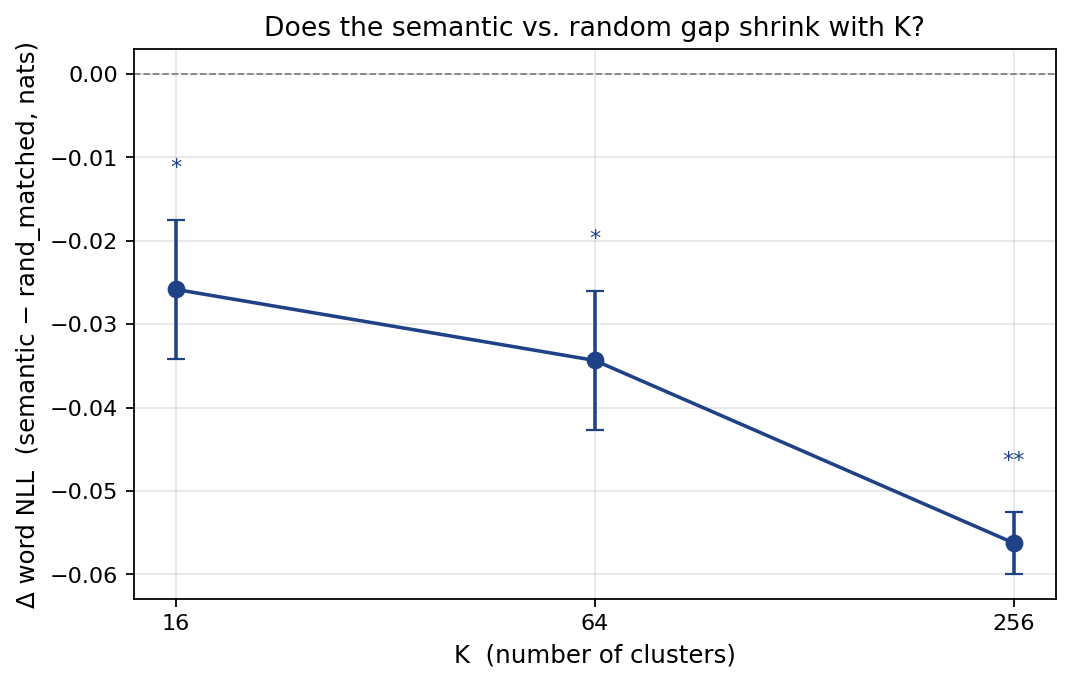

In [14]:
from IPython.display import Image
Image("/kaggle/working/hdlm_tier1/delta_vs_K.png")